# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [2]:
!git clone https://github.com/ciara-graves/linear_models.git

fatal: destination path 'linear_models' already exists and is not an empty directory.


In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

df=pd.read_csv('/content/linear_models/lab/data/pierce_county_house_sales.csv')
df.head()

,sale_date,sale_price,house_square_feet,attic_finished_square_feet,basement_square_feet,attached_garage_square_feet,detached_garage_square_feet,fireplaces,hvac_description,exterior,interior,stories,roof_cover,year_built,bedrooms,bathrooms,waterfront_type,view_quality,utility_sewer
0,2020-01-02,380000,2157,0,0,528,0,0,Warm and Cool Air Zone,Frame Siding,Drywall,2,Composition Shingle,1993,3,3,NaN,NaN,SEWER/SEPTIC INSTALLED
1,2020-01-02,383000,2238,0,0,396,0,0,Forced Air,Frame Siding,Drywall,2,Composition Shingle,2017,4,3,NaN,NaN,SEWER/SEPTIC INSTALLED
2,2020-01-01,419900,1452,0,0,0,0,1,Forced Air,Frame Siding,Drywall,1,Built Up Rock,1965,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED
3,2020-01-02,251660,832,0,0,0,0,0,Forced Air,Frame Vinyl,Drywall,1,Composition Shingle,1919,2,1,NaN,NaN,SEWER/SEPTIC INSTALLED
4,2020-01-02,500000,1780,0,384,484,0,1,Forced Air,Frame Siding,Drywall,1,Composition Shingle,1955,3,2,NaN,NaN,SEWER/SEPTIC INSTALLED


    sale_date  sale_price  house_square_feet  attic_finished_square_feet  \
0  2020-01-02      380000               2157                           0   
1  2020-01-02      383000               2238                           0   
2  2020-01-01      419900               1452                           0   
3  2020-01-02      251660                832                           0   
4  2020-01-02      500000               1780                           0   

   basement_square_feet  attached_garage_square_feet  \
0                     0                          528   
1                     0                          396   
2                     0                            0   
3                     0                            0   
4                   384                          484   

   detached_garage_square_feet  fireplaces        hvac_description  \
0                            0           0  Warm and Cool Air Zone   
1                            0           0              Forced Air

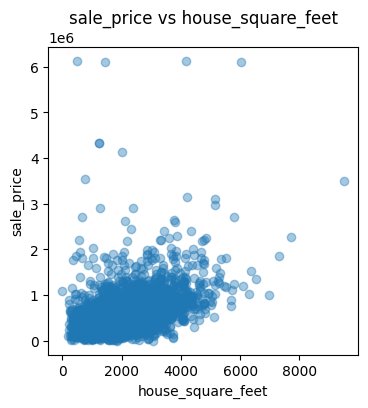

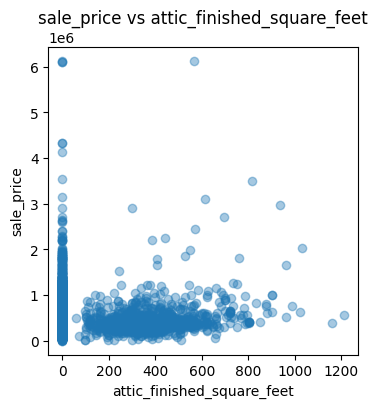

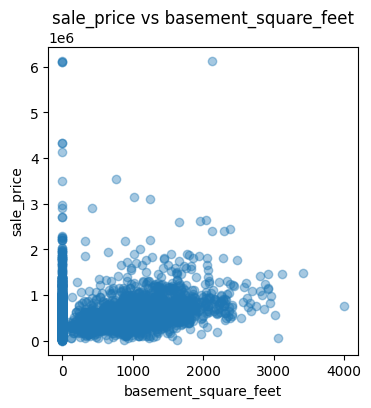

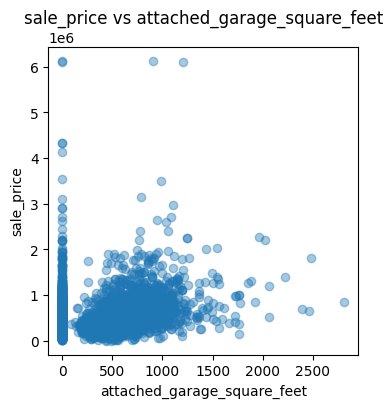

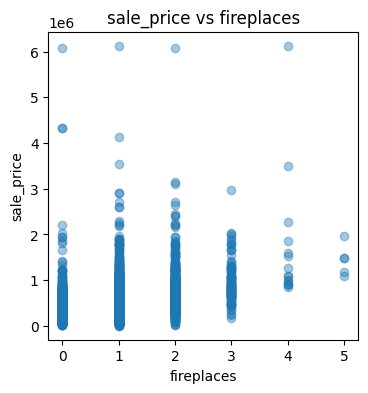

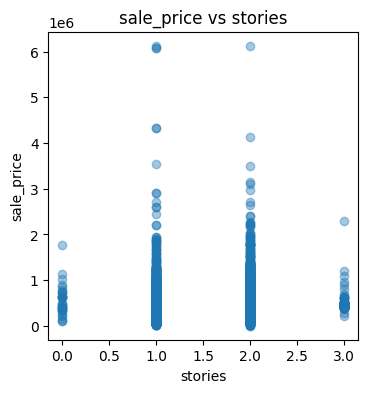

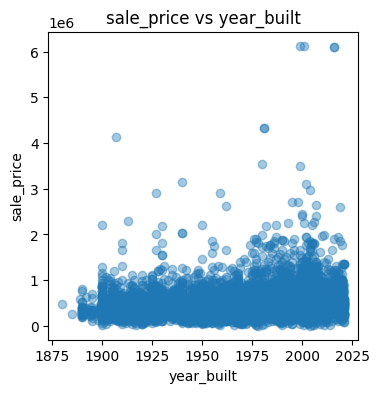

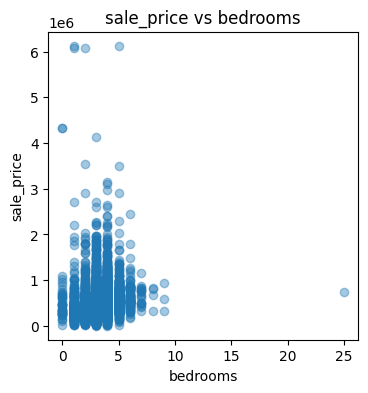

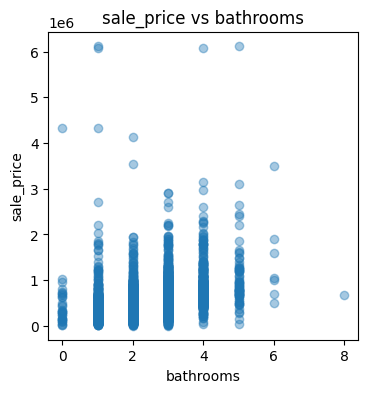

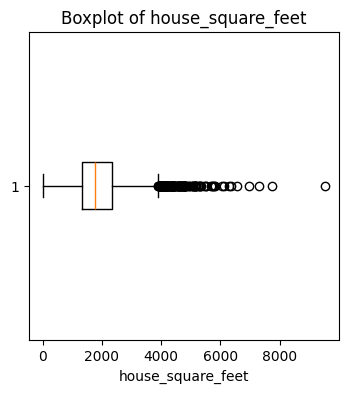

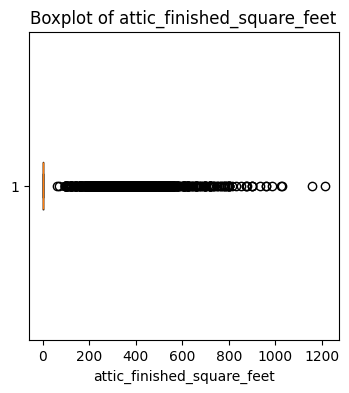

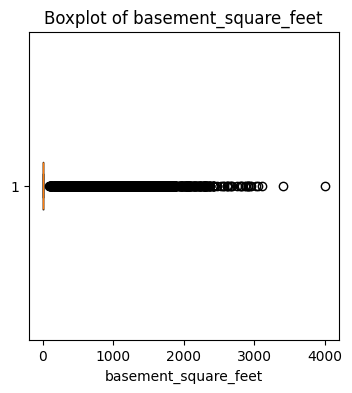

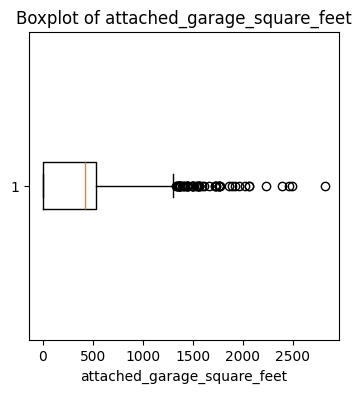

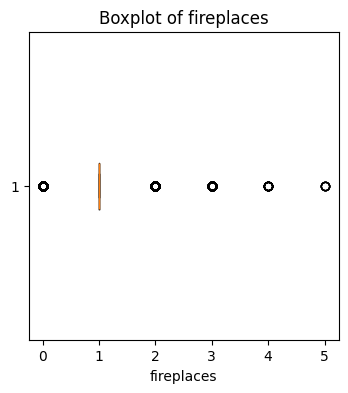

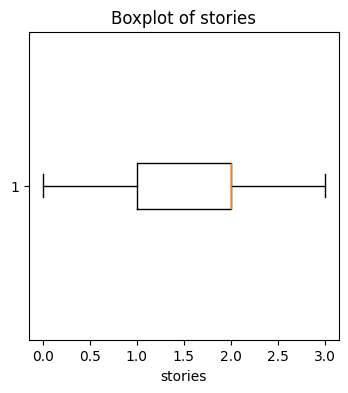

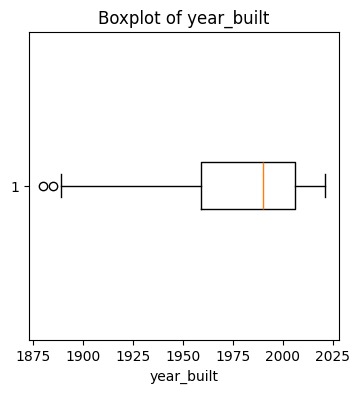

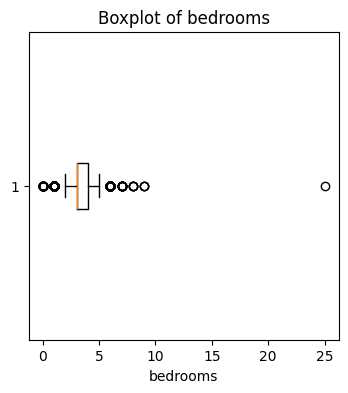

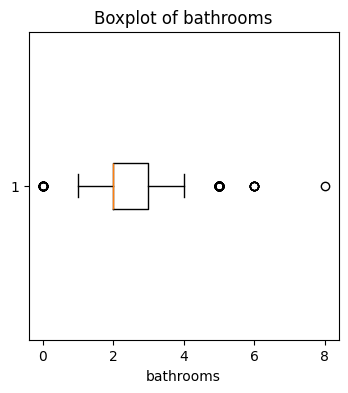

<Figure size 400x400 with 0 Axes>

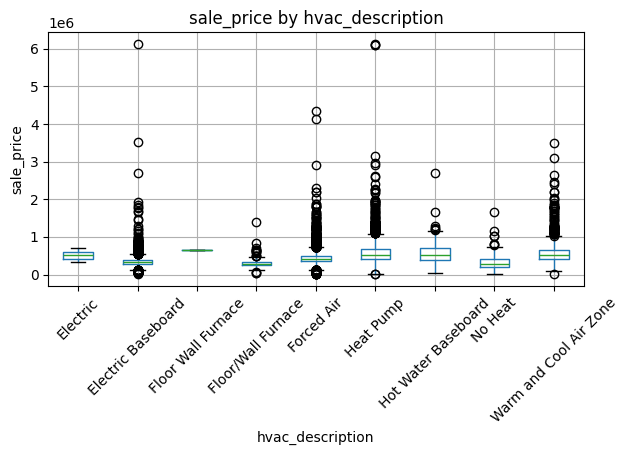

<Figure size 400x400 with 0 Axes>

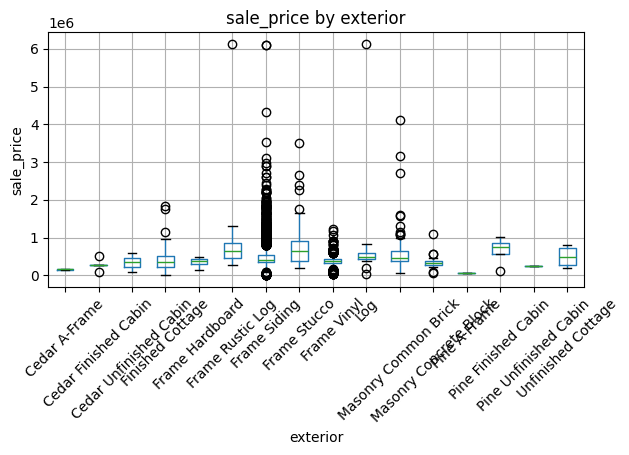

<Figure size 400x400 with 0 Axes>

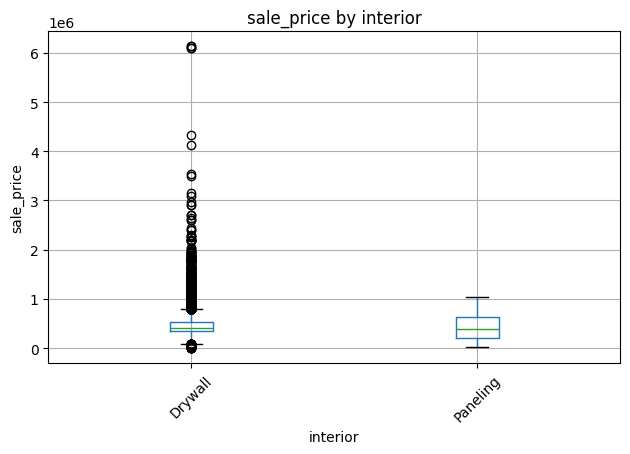

<Figure size 400x400 with 0 Axes>

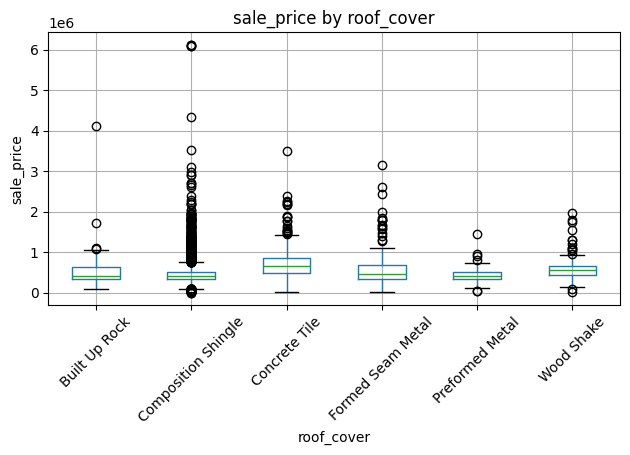

<Figure size 400x400 with 0 Axes>

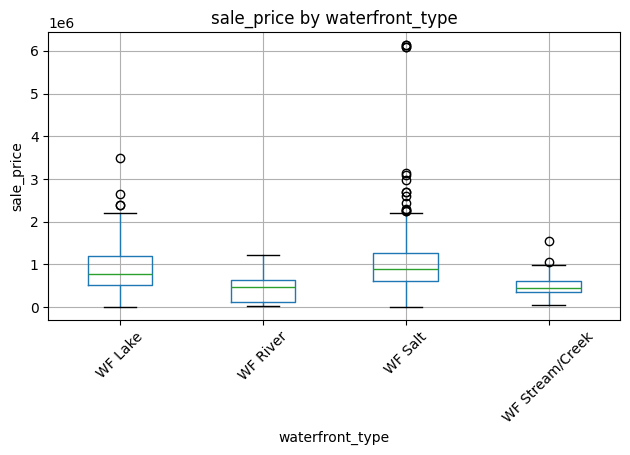

<Figure size 400x400 with 0 Axes>

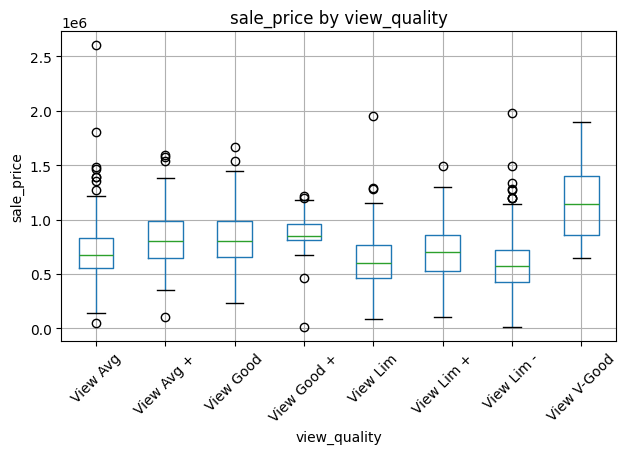

<Figure size 400x400 with 0 Axes>

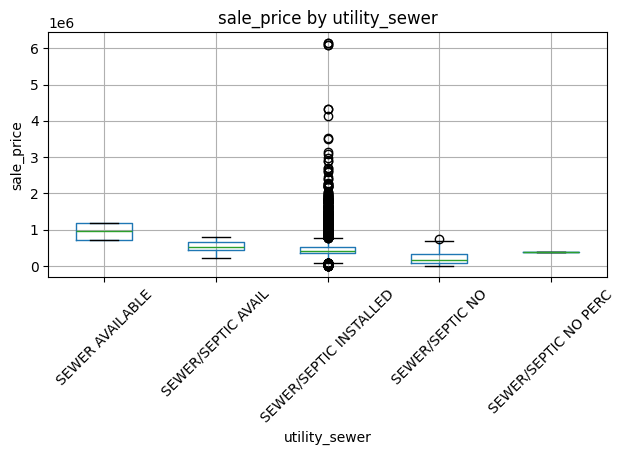

hvac_description
Forced Air                10382
Electric Baseboard         2668
Heat Pump                  2084
Warm and Cool Air Zone     1268
Floor/Wall Furnace          174
Hot Water Baseboard         146
No Heat                      82
NaN                           7
Electric                      2
Floor Wall Furnace            1
Name: count, dtype: int64
exterior
Frame Siding              14577
Frame Vinyl                1724
Masonry Common Brick        208
Frame Stucco                156
Masonry Concrete Block       43
Finished Cottage             41
Frame Rustic Log             21
Log                          12
Frame Hardboard              11
Cedar Finished Cabin          5
Unfinished Cottage            4
Pine Finished Cabin           4
Cedar A-Frame                 2
Pine Unfinished Cabin         2
Cedar Unfinished Cabin        2
NaN                           1
Pine A-Frame                  1
Name: count, dtype: int64
interior
Drywall     16777
Paneling       30
NaN          

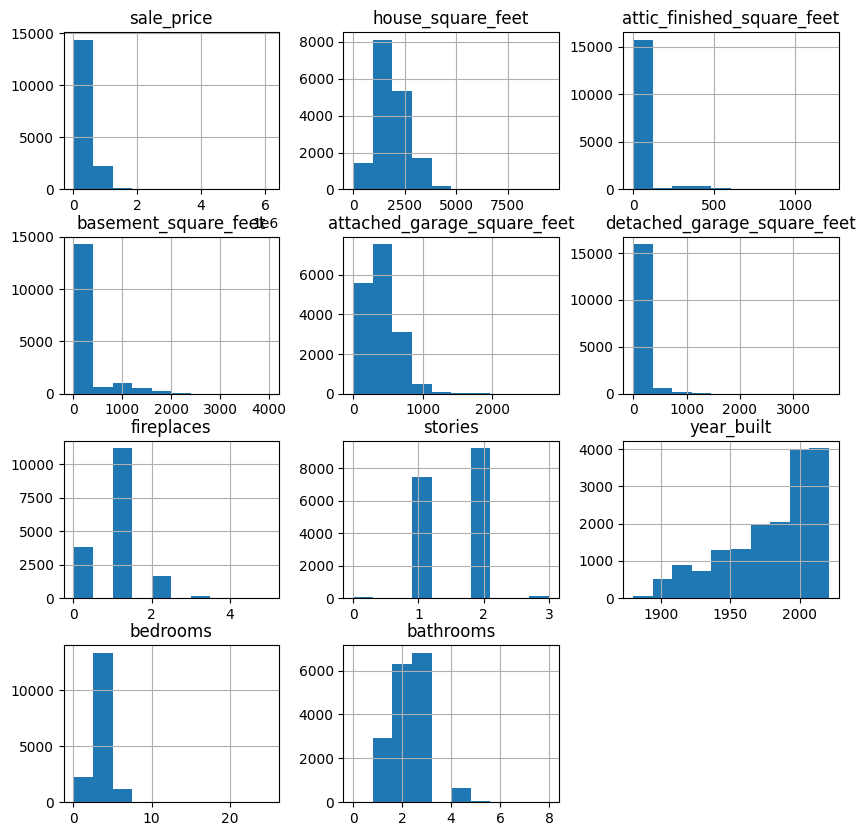

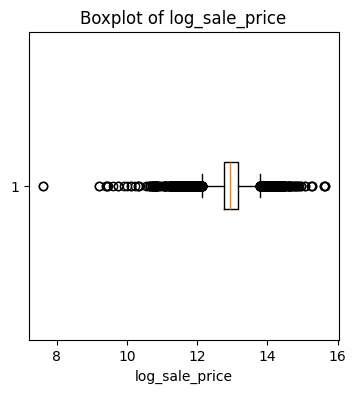

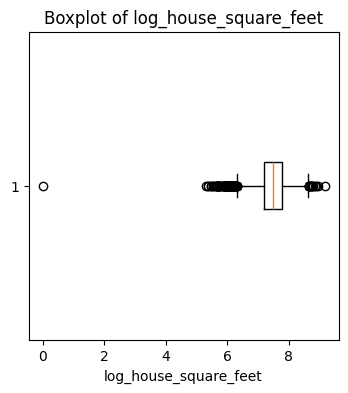

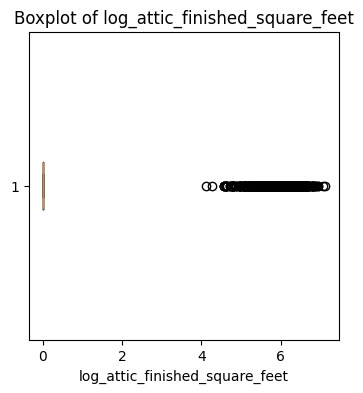

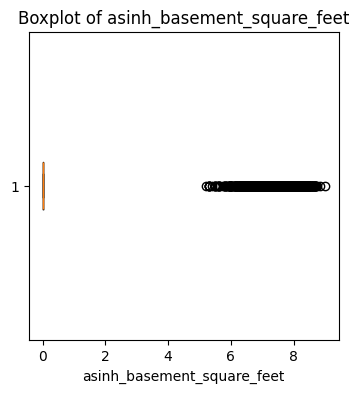

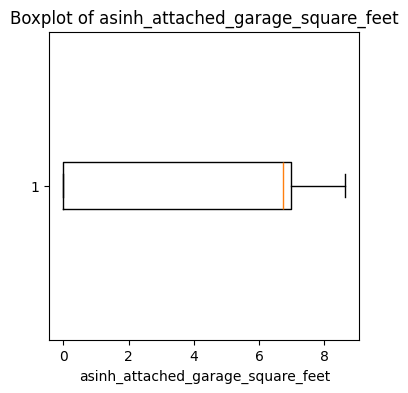

In [24]:
## Part 1 & 2: perform EDA and clean/transform data
df=pd.read_csv('/content/linear_models/lab/data/pierce_county_house_sales.csv')
# response:

# numerical variables:
# `sale_price`, `house_square_feet`, `attic_finished_square_feet`, `basement_square_feet`,
# `attached_garage_square_feet`, `fireplaces`, `stories`, `year_built`, `bedrooms`, `bathrooms`,
# define num vars (will use later)
num_vars = ['house_square_feet','attic_finished_square_feet',
    'basement_square_feet','attached_garage_square_feet','fireplaces',
    'stories','year_built','bedrooms','bathrooms']
# categorical variables:
# 'hvac_description`, `exterior`, `interior`, `roof_cover`, `waterfront_type`, `view_quality`,
# `utility_sewer`
# def'n cat vars
cat_vars = ['hvac_description','exterior','interior','roof_cover',
            'waterfront_type','view_quality','utility_sewer']

## EDA
print(df.head())
print(df.info())
print(df[num_vars].describe())
print(df[cat_vars].describe())
# summary stats on response
summary_stats = df['sale_price'].describe()
print(summary_stats)
print("\nMissing values:")
print(df[num_vars + cat_vars].isna().sum())

# scatterplots of y vs numeric/cont x's (check to see if all numeric vars are cont)
# also gives idea for outliers and skewness
resp = 'sale_price'
predict_num_vars = [var for var in num_vars if var != resp]
for var in predict_num_vars:
    plt.figure(figsize=(4, 4))
    plt.scatter(df[var], df[resp], alpha=0.4)
    plt.xlabel(var)
    plt.ylabel(resp)
    plt.title(f"{resp} vs {var}")
    plt.show()

# contin vs categor varis: boxplots
for var in num_vars:
    plt.figure(figsize=(4, 4))
    plt.boxplot(df[var].dropna(), vert=False)
    plt.title(f"Boxplot of {var}")
    plt.xlabel(var)
    plt.show()


for var in cat_vars:
    plt.figure(figsize=(4, 4))
    df.boxplot(column=resp, by=var, rot=45)
    plt.title(f"{resp} by {var}")
    plt.suptitle("")  # removes automatic pandas subtitle
    plt.xlabel(var)
    plt.ylabel(resp)
    plt.tight_layout()
    plt.show()
# histograms for each var
histograms = df.hist(figsize=(10, 10))



# for cat variables, check vals with na's
print(df['hvac_description'].value_counts(dropna=False))
print(df['exterior'].value_counts(dropna=False))
print(df['interior'].value_counts(dropna=False))
print(df['roof_cover'].value_counts(dropna=False))
print(df['utility_sewer'].value_counts(dropna=False))
# for waterfront and viewquality, make na's = no and value 0
print(df['waterfront_type'].value_counts())
print(df['view_quality'].value_counts())

# now make cat vars dummys (with intercept to avoid multicollin)
df = pd.get_dummies(df, columns=['hvac_description',
                                 'exterior','interior','roof_cover',
                                 'utility_sewer','waterfront_type',
                                 'view_quality'], drop_first=True)
# for numerical vars, get idea of any missing data
print(df['sale_price'].value_counts(dropna=False))
print(df['house_square_feet'].value_counts(dropna=False))
print(df['attic_finished_square_feet'].value_counts(dropna=False))
print(df['basement_square_feet'].value_counts(dropna=False))
print(df['attached_garage_square_feet'].value_counts(dropna=False))
print(df['fireplaces'].value_counts(dropna=False))
print(df['bathrooms'].value_counts(dropna=False))
print(df['stories'].value_counts(dropna=False))
print(df['year_built'].value_counts(dropna=False))
print(df['bedrooms'].value_counts(dropna=False))

# log-transformation for heavy tailed num vars
df['log_sale_price'] = np.log(df['sale_price'])
#df['log_attached_garage_square_feet'] = np.log(df['attached_garage_square_feet'])
df['log_house_square_feet'] = np.log(df['house_square_feet'])
# has 0's so log1p
df['log_attic_finished_square_feet'] = np.log1p(df['attic_finished_square_feet'])
#df['log_basement_square_feet'] = np.log(df['basement_square_feet'])
# arcsinh trans
df['asinh_attached_garage_square_feet'] = np.arcsinh(df['attached_garage_square_feet'])
df['asinh_basement_square_feet'] = np.arcsinh(df['basement_square_feet'])
#df['asinh_attic_finished_square_feet'] = np.arcsinh(df['attic_finished_square_feet'])
#df['asinh_house_square_feet'] = np.arcsinh(df['house_square_feet'])
#df['asinh_sale_price'] = np.arcsinh(df['sale_price'])
# check boxplots again
trans_num_vars = ['log_sale_price','log_house_square_feet',
                  'log_attic_finished_square_feet',
                  'asinh_basement_square_feet',
                'asinh_attached_garage_square_feet']
for var in trans_num_vars:
    plt.figure(figsize=(4, 4))
    plt.boxplot(df[var].dropna(), vert=False)
    plt.title(f"Boxplot of {var}")
    plt.xlabel(var)
    plt.show()



In [18]:
##  Part 3: Implement an 80/20 train-test split.
train1, test1 = train_test_split(df, test_size=0.2, random_state=123)

#Put the test data aside.

In [28]:
# Part 4: Build some simple linear models that include no transformations or interactions.
# build design matrics

# true simple linear models (one predictor)
X_train_dict = {}
X_test_dict = {}

for var in num_vars:
    X_train_dict[var] = train1[[var]]
    X_test_dict[var] = test1[[var]]
results = []

for var in num_vars:
    X_train = train1[[var]]
    X_test = test1[[var]]

    y_train = train1['sale_price']
    y_test = test1['sale_price']

    model = LinearRegression().fit(X_train, y_train)

    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    results.append({
        'variable': var,
        'train_r2': r2_score(y_train, pred_train),
        'test_r2': r2_score(y_test, pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_train, pred_train)),
        'test_rmse': np.sqrt(mean_squared_error(y_test, pred_test))
    })
results_df = pd.DataFrame(results).sort_values('test_rmse')
results_df

X_train2 = train1[['house_square_feet', 'year_built','bedrooms']]
X_test2 = test1[['house_square_feet', 'year_built','bedrooms']] # Corrected: use test1
# fit model
model2 = LinearRegression()
model2.fit(X_train2, y_train)
pred2 = model2.predict(X_test2)
r2_2 = r2_score(y_test, pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, pred2))
print("Test R^2:", r2_2)
print("Test RMSE:", rmse_2)

X_train3 = train1[['house_square_feet', 'bathrooms','fireplaces']]
X_test3 = test1[['house_square_feet', 'bathrooms','fireplaces']] # Corrected: use test1
# fit model
model3 = LinearRegression()
model3.fit(X_train3, y_train)
pred3 = model3.predict(X_test3) # Corrected: use X_test3 for prediction
r2_3 = r2_score(y_test, pred3) # Corrected: r3_score to r2_score and pred2 to pred3
rmse_3 = np.sqrt(mean_squared_error(y_test, pred3))
print("Test R^2:", r2_3)
print("Test RMSE:", rmse_3)
results_df = pd.DataFrame(results).sort_values('test_rmse')
results_df

# Fit them, and determine their RMSE and  R2  on the both the training and test sets.


# Which of your models does the best?

Test R^2: 0.31565000465989124
Test RMSE: 179821.0609702395
Test R^2: 0.3059739281122693
Test RMSE: 181087.85069585498


,variable,train_r2,test_r2,train_rmse,test_rmse
0,house_square_feet,0.273727,0.292555,204973.192178,182830.174725
8,bathrooms,0.169605,0.157167,219174.251355,199559.385064
4,fireplaces,0.120192,0.127001,225600.970592,203099.295774
3,attached_garage_square_feet,0.096081,0.098461,228671.444068,206392.421521
2,basement_square_feet,0.074791,0.061756,231348.630977,210551.953634
6,year_built,0.050493,0.061159,234366.827443,210618.899427
7,bedrooms,0.041593,0.044949,235462.664862,212429.485723
5,stories,0.027924,0.026237,237135.814182,214500.426903
1,attic_finished_square_feet,0.000626,-0.000812,240442.395512,217459.142585


In [29]:
# Part 5: Make partial correlation plots for each of the numeric variables in your model.
# def residuals
residuals = model_sm.resid
for var in features:
    beta = model_sm.params[var]
    partial_resid = residuals + beta * X_train[var]

    plt.figure(figsize=(5, 4))
    plt.scatter(X_train[var], partial_resid, alpha=0.4)
    plt.title(f"Partial Residual Plot: {var}")
    plt.xlabel(var)
    plt.ylabel("Partial Residual")
    plt.show()

# Do you notice any significant non-linearities?

NameError: name 'model_sm' is not defined

In [ ]:
# Part 6: Include transformations and interactions of your variables, and build
# a more complex model that reflects your ideas about how the features of the
# asset determine its value.


# Determine its RMSE and  R2  on the training and test sets.

# How does the more complex model your build compare to the simpler ones?

**Part 7: Summarize findings from parts 1-6**
Part 1: what did eda find


*   some numeric variables like fireplaces and stories built are numeric, but discrete (not continupous). Left untransformed, but are suggestive to be non-linear and may effect the overall model. At the covariate level, they can be non-linear, but if the model is struggly to satifiy it's assumptions, then may want to consider removing them. Doesn't make sense to transform them. We could model tham as categorical predictors.
*   for vairblaes like `house_square_feet` and `attic_finished_square_feet`, we are observing long right tails with many high value observations. This can be understood as large homes have large square feet values. These are not outliers, however we should consider log transformation to reduction skew and improve linear regression assumptions.

Part 2: How did we transform the variables (esp cat)
*   List item

Part 3: that was 80/20 train/test (no notes)

Part 4: building simple linear models without interactions and transformations.
Which of the models perform the best, reerence RMSE and $R^2$
*   List item

Part 5: partial correlation plots for each numeric variable in model.
Note any significant non-linearities
*   List item

Part 6: Add transformations and interactions to build a more complex model.
How does the more complex model compare to the simpler ones?
*   List item

Talk about how we might want to use stepwise regression as a means to determine
